In [1]:
# data analysis
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import re

# visualization
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# machine learning
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV



# kaggle settings
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [2]:
train = pd.read_csv('/kaggle/input/titanic/train.csv')
test = pd.read_csv('/kaggle/input/titanic/test.csv')

### Exploratory analysis

Survived - is a target.

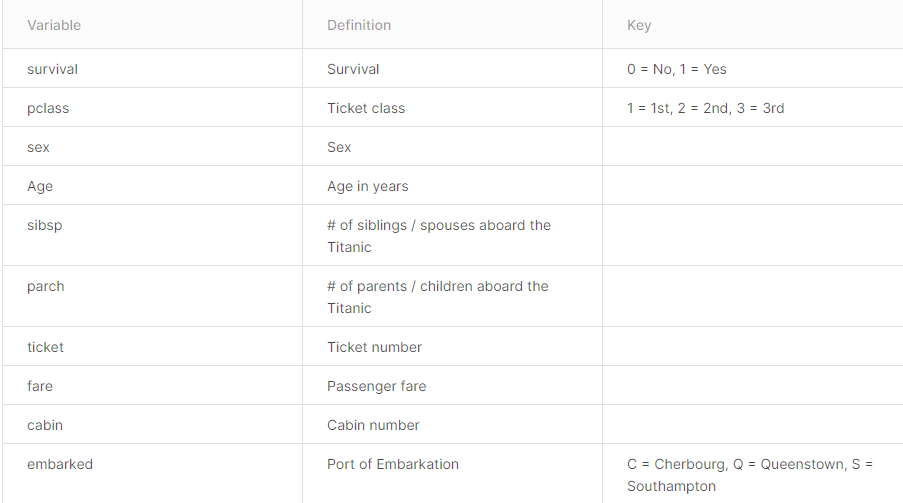

Most likely there will be no need in id, ticket and cabin numbers.

In [3]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
train.info() #some variables have nulls

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


In [7]:
train.describe() #statistics of num variables

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Let's see at the distributions of survived passegers depending on different features.

In [8]:
train['Survived'].value_counts()

0    549
1    342
Name: Survived, dtype: int64

In [9]:
train.groupby('Sex', as_index=False).Survived.aggregate(['mean', 'count', 'sum'])

,mean,count,sum
Sex,,,
female,0.742038,314,233
male,0.188908,577,109


In [10]:
train.groupby('Pclass', as_index=False).Survived.aggregate(['mean', 'count', 'sum'])

,mean,count,sum
Pclass,,,
1,0.629630,216,136
2,0.472826,184,87
3,0.242363,491,119


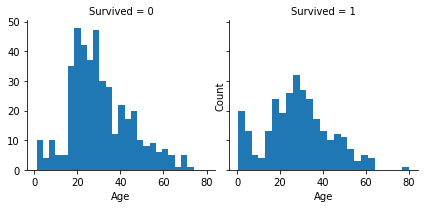

In [11]:
sns.FacetGrid(train, col='Survived').map(plt.hist, 'Age', bins=25)
plt.ylabel('Count');

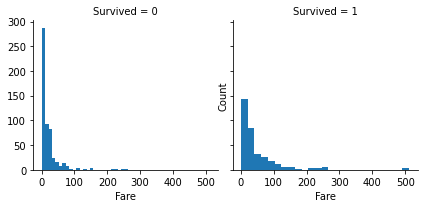

In [12]:
sns.FacetGrid(train, col='Survived').map(plt.hist, 'Fare', bins=25)
plt.ylabel('Count');

In [13]:
train.groupby('SibSp', as_index=False).Survived.aggregate(['mean', 'count', 'sum'])

,mean,count,sum
SibSp,,,
0,0.345395,608,210
1,0.535885,209,112
2,0.464286,28,13
3,0.250000,16,4
4,0.166667,18,3
5,0.000000,5,0
8,0.000000,7,0


In [14]:
train.groupby('Parch', as_index=False).Survived.aggregate(['mean', 'count', 'sum'])

,mean,count,sum
Parch,,,
0,0.343658,678,233
1,0.550847,118,65
2,0.500000,80,40
3,0.600000,5,3
4,0.000000,4,0
5,0.200000,5,1
6,0.000000,1,0


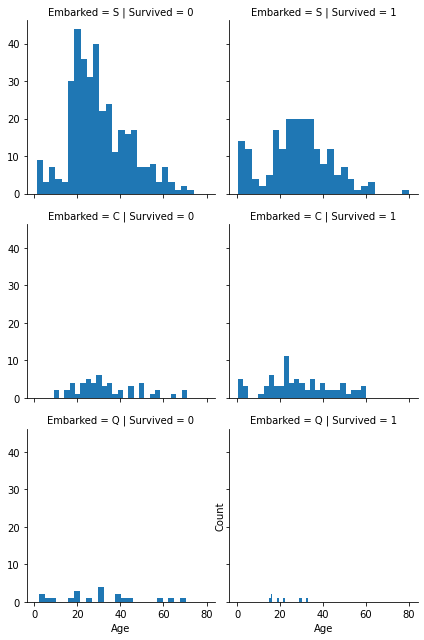

In [15]:
sns.FacetGrid(train, col='Survived',row='Embarked').map(plt.hist, 'Age', bins=25)
plt.ylabel('Count');

### Interim conclusions 

Now after small analysis we can say that there were total of 891 people on the ship with 314 women (74% survived) and 577 man (19% survived). In total there were more people who didn't manage to survive.  
People from 1st class had more chances to survive than from 3rd.  
People in the age group of ~20-35 years prevail among the survivors and those who did not survive.  
Passangers with 1-2 siblings aboard more likely survived.

### Feature engineering

We can also do some feature engineering by creating new features.

In [16]:
result = []
for line in train['Name']:
    result.append(line[line.find(',')+2 : line.find('.')])
train['Title'] = result

resulttest = []
for line in test['Name']:
    resulttest.append(line[line.find(',')+2 : line.find('.')])
test['Title'] = resulttest

In [17]:
train.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S,Rev
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S,Miss
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S,Miss
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C,Mr
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q,Mr


In [18]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,Mr
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,Mrs
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,Mr
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,Mr
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,Mrs


In [19]:
train.groupby('Title', as_index=False).Survived.aggregate(['mean', 'count', 'sum'])

,mean,count,sum
Title,,,
Capt,0.000000,1,0
Col,0.500000,2,1
Don,0.000000,1,0
Dr,0.428571,7,3
Jonkheer,0.000000,1,0
Lady,1.000000,1,1
Major,0.500000,2,1
Master,0.575000,40,23
Miss,0.697802,182,127


Let's agrergate the titles

In [20]:
train['Title'] = train['Title'].replace(['Lady', 'Mme', 'Mlle', 'the Countess'], 'Ms')
train['Title'] = train['Title'].replace(['Sir', 'Master'], 'Mr')
train['Title'] = train['Title'].replace(['Capt', 'Col', 'Don', 'Dr','Jonkheer', 'Rev', 'Major' ], 'Other')

test['Title'] = test['Title'].replace(['Lady', 'Mme', 'Mlle', 'the Countess'], 'Ms')
test['Title'] = test['Title'].replace(['Sir', 'Master'], 'Mr')
test['Title'] = test['Title'].replace(['Capt', 'Col', 'Don', 'Dr','Jonkheer', 'Rev', 'Major', 'Dona' ], 'Other')

In [21]:
train.groupby('Title', as_index=False).Survived.mean().sort_values(by='Survived', ascending=False)

,Title,Survived
3,Ms,1.000000
2,Mrs,0.792000
0,Miss,0.697802
4,Other,0.250000
1,Mr,0.188172


In [22]:
np.unique(test.Title)

array(['Miss', 'Mr', 'Mrs', 'Ms', 'Other'], dtype=object)

In [23]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
train['Title'] = le.fit_transform(np.array(train['Title']).reshape(-1, 1))
test['Title'] = le.transform(np.array(test['Title']).reshape(-1, 1))
# male - 1, female - 0
train['Sex'] = le.fit_transform(train['Sex'])
test['Sex'] = le.transform(test['Sex'])

/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:72: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(**kwargs)


We can also combine some age digits and fare into groups. In addition let's unite SibSp and ParCh.

In [24]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
Title            0
dtype: int64

In [25]:
test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
Title            0
dtype: int64

We have some missing values in Age and Fare (do not take into account Cabin feature because I'm gonna drop it).

In [26]:
from sklearn.impute import SimpleImputer
si=SimpleImputer(strategy='mean')
train['Age'] = si.fit_transform(np.array(train['Age']).reshape(-1, 1))
test['Age'] = si.transform(np.array(test['Age']).reshape(-1, 1))

In [27]:
median = test["Fare"].median()
test['Fare'].fillna(median, inplace=True)

In [28]:
train['FamSize'] = train['SibSp'] + train ['Parch']
test['FamSize'] = test['SibSp'] + test ['Parch']

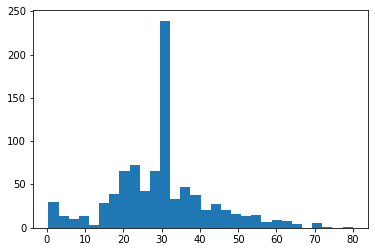

In [29]:
plt.hist(x=train['Age'], bins=30);

In [30]:
train['AgeSegm'] = train['Age'].apply(lambda x: 1 if (x >= 0) & (x < 20) else 2 if (x >= 20) & (x < 40) else 3 if (x >= 40) & (x < 60) else 4
                                      if (x >= 60) & (x <= 80) else 0) 
test['AgeSegm'] = test['Age'].apply(lambda x: 1 if (x >= 0) & (x < 20) else 2 if (x >= 20) & (x < 40) else 3 if (x >= 40) & (x < 60) else 4
                                      if (x >= 60) & (x <= 80) else 0) 

In [31]:
train['AgeSegm'].unique()

array([2, 3, 1, 4])

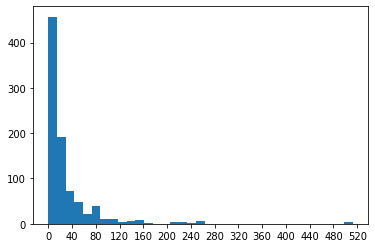

In [32]:
plt.hist(train['Fare'], bins = 35)
plt.xticks(np.arange(0, max(train['Fare'])+20, 40));

In [33]:
train['FareSegm'] = train['Fare'].apply(lambda x: 1 if (x >= 0) & (x < 15) else 2 if (x >= 15) & (x < 80) else 3 if (x >= 80) else 0) 
test['FareSegm'] = test['Fare'].apply(lambda x: 1 if (x >= 0) & (x < 15) else 2 if (x >= 15) & (x < 80) else 3 if (x >= 80) else 0) 

In [34]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamSize,AgeSegm,FareSegm
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S,1,1,2,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C,2,1,2,2
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,0,2,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S,2,1,2,2
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,S,1,0,2,1


Now let's drop some columns

In [35]:
train_df = train.drop(['PassengerId','Name','Ticket', 'Cabin', 'Embarked','SibSp','Parch', 'Age', 'Fare'], axis=1)
test_df = test.drop(['PassengerId','Name','Ticket', 'Cabin', 'Embarked','SibSp','Parch',  'Age', 'Fare'], axis=1)

In [36]:
train_df.head()

,Survived,Pclass,Sex,Title,FamSize,AgeSegm,FareSegm
0,0,3,1,1,1,2,1
1,1,1,0,2,1,2,2
2,1,3,0,0,0,2,1
3,1,1,0,2,1,2,2
4,0,3,1,1,0,2,1


### Fit-Predict part

In whis part I'm gonna compare some algoritms, scores.

In [37]:
X_train = train_df.drop("Survived", axis=1)
y_train = train_df["Survived"]
X_test  = test_df.copy()
X_train.shape, y_train.shape, X_test.shape

((891, 6), (891,), (418, 6))

#### Decision Trees

**Main Advantages:**  
Intuitive classification model  
Fast learning process

**Main disadvantages:**  
Often overfit  
Vary a lot with a small change in the sample

In [38]:
tree = DecisionTreeClassifier(random_state=1)
tree.get_params().keys()

dict_keys(['ccp_alpha', 'class_weight', 'criterion', 'max_depth', 'max_features', 'max_leaf_nodes', 'min_impurity_decrease', 'min_impurity_split', 'min_samples_leaf', 'min_samples_split', 'min_weight_fraction_leaf', 'presort', 'random_state', 'splitter'])

In [39]:
params = {'max_depth': range (4,10),
          'min_samples_leaf': range(1, 9),
          'min_samples_split': range (2,10,2)}

gs = GridSearchCV(tree,params, scoring='accuracy', cv=10, n_jobs=-1, refit = True)

In [40]:
gs.fit(X_train, y_train)
print('best params: ', gs.best_params_)
print('best score: ', gs.best_score_)
dt_score = round(gs.best_score_*100,2)

best params:  {'max_depth': 6, 'min_samples_leaf': 7, 'min_samples_split': 2}
best score:  0.8204744069912608


In [41]:
Y_pred_tree = gs.predict(X_test)

#### Logistic Regression

**Main Advantages:**  
Good in binary classification  
Fast learning process and clarity

**Main disadvantages:**  
It can only classify relatively simple objects  
Not suitable for dividing objects into several classes. 

In [42]:
lg = LogisticRegression(random_state=1)
lg.get_params().keys()

dict_keys(['C', 'class_weight', 'dual', 'fit_intercept', 'intercept_scaling', 'l1_ratio', 'max_iter', 'multi_class', 'n_jobs', 'penalty', 'random_state', 'solver', 'tol', 'verbose', 'warm_start'])

In [43]:
params_lg = {'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'],
          'max_iter': range(40, 100, 10)}

gs_lg = GridSearchCV(lg,params_lg, scoring='accuracy', cv=10, n_jobs=-1, refit = True)

In [44]:
gs_lg.fit(X_train, y_train)
print('best params: ', gs_lg.best_params_)
print('best score: ', gs_lg.best_score_)
lg_score = round(gs_lg.best_score_ * 100,2)

best params:  {'max_iter': 40, 'solver': 'liblinear'}
best score:  0.809238451935081


In [45]:
Y_pred_lg = gs.predict(X_test)

#### kNN

**Main Advantages:**  
Resistance to outliers and anomalous values, since the probability of the records containing them falling into the number of k-nearest neighbors is small;  
Simple implementation and easy to interpret.

**Main disadvantages:**  
Poorly distinguishes objects that are too similar. Sometimes it can incorrectly determine the class of objects even after carefully calibrating the model;  
Slower than decision tree in case of large dataset;  
There is no theoretical basis for choosing a certain number of neighbors. 

In [46]:
knn = KNeighborsClassifier()
knn.get_params().keys()

dict_keys(['algorithm', 'leaf_size', 'metric', 'metric_params', 'n_jobs', 'n_neighbors', 'p', 'weights'])

In [47]:
params_knn = {'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
          'n_neighbors': range(3, 50, 2),
           'leaf_size': range(15, 50, 5)
                                       }
gs_knn = GridSearchCV(knn,params_knn, scoring='accuracy', cv=10, n_jobs=-1, refit = True)

In [48]:
gs_knn.fit(X_train, y_train)
print('best params: ', gs_knn.best_params_)
print('best score: ', gs_knn.best_score_)
knn_score = round(gs_knn.best_score_ * 100,2)

best params:  {'algorithm': 'ball_tree', 'leaf_size': 15, 'n_neighbors': 17}
best score:  0.8148189762796504


In [49]:
Y_pred_knn = gs_knn.predict(X_test)

#### Naive Bayes

**Main Advantages:**  
Classification, including multi-class, is easy and fast;  
When the independence assumption is met, NBA outperforms other algorithms, such as logistic regression, and requires less train data.

**Main disadvantages:**  
If there is some categorical attribute value in the test data that did not occur in the train data, then the model will assign a zero probability to this value and will not be able to make a prediction (zero frequency can be solved using Laplace smoothing);  
The values of the predicted probabilities are not always accurate enough. 

In [50]:
nb = GaussianNB()
nb.get_params().keys()

dict_keys(['priors', 'var_smoothing'])

In [51]:
nb.fit(X_train, y_train)
print('score: ', nb.score(X_train, y_train))
nb_score = round(nb.score(X_train, y_train) * 100,2)

score:  0.7811447811447811


In [52]:
Y_pred_nb = nb.predict(X_test)

#### SVM (Support Vector Machines)

**Main Advantages:**  
Works well with small data;  
Works well with large feature space.

**Main disadvantages:**  
Long training time (for large datasets);  
Instability to noise: outliers in the training data directly affect the construction of the separating hyperplane.

In [53]:
svm = SVC(random_state = 1)
svm.get_params().keys()

dict_keys(['C', 'break_ties', 'cache_size', 'class_weight', 'coef0', 'decision_function_shape', 'degree', 'gamma', 'kernel', 'max_iter', 'probability', 'random_state', 'shrinking', 'tol', 'verbose'])

In [54]:
svm.fit(X_train, y_train)
print('score: ', svm.score(X_train, y_train))
svm_score = round(svm.score(X_train, y_train) * 100,2)

score:  0.8226711560044894


In [55]:
Y_pred_svm = svm.predict(X_test)

#### Random Forest

**Main Advantages:**  
Has a high prediction accuracy;  
Practically insensitive to data outliers due to random sampling;  
Is able to efficiently process data with a large number of features and classes;  
Rerely overfits.

**Main disadvantages:**  
Difficult to interpret;  
Is prone to overfitting on some tasks, especially on noisy data;  
Larger size of the resulting models.

In [56]:
rf = RandomForestClassifier(random_state=1)
rf.get_params().keys()

dict_keys(['bootstrap', 'ccp_alpha', 'class_weight', 'criterion', 'max_depth', 'max_features', 'max_leaf_nodes', 'max_samples', 'min_impurity_decrease', 'min_impurity_split', 'min_samples_leaf', 'min_samples_split', 'min_weight_fraction_leaf', 'n_estimators', 'n_jobs', 'oob_score', 'random_state', 'verbose', 'warm_start'])

In [57]:
params_rf = {'n_estimators': range(10, 100, 10),
           'max_depth': range (4,10),
          'min_samples_leaf': range(1, 9),
          'min_samples_split': range (2,10,2)
                                       }
gs_rf = GridSearchCV(rf,params_rf, scoring='accuracy', cv=10, n_jobs=-1, refit = True)

In [58]:
gs_rf.fit(X_train, y_train)
print('best params: ', gs_rf.best_params_)
print('best score: ', gs_rf.best_score_)
rf_score = round(gs_rf.best_score_ * 100, 2)

best params:  {'max_depth': 9, 'min_samples_leaf': 6, 'min_samples_split': 2, 'n_estimators': 80}
best score:  0.8283021223470662


In [59]:
Y_pred_rf = gs_rf.predict(X_test)

#### SGD (Stochastic Gradient Descent)

**Main Advantages:**  
Efficiency;  
Ease of implementation.  

**Main disadvantages:**  
Requires a number of hyperparameters such as the regularization parameter and the number of iterations;  
Is sensitive to feature scaling.

In [60]:
sgd = SGDClassifier(random_state = 1, early_stopping = True)
sgd.get_params().keys()

dict_keys(['alpha', 'average', 'class_weight', 'early_stopping', 'epsilon', 'eta0', 'fit_intercept', 'l1_ratio', 'learning_rate', 'loss', 'max_iter', 'n_iter_no_change', 'n_jobs', 'penalty', 'power_t', 'random_state', 'shuffle', 'tol', 'validation_fraction', 'verbose', 'warm_start'])

In [61]:
params_sgd = {'loss': ['hinge', 'log', 'modified_huber', 'squared_hinge', 'perceptron'],
           'max_iter': range(100, 1000, 20),
            'learning_rate': ['constant', 'optimal', 'invscaling', 'adaptive'],
              'eta0':[0.001, 0.005, 0.01]
                                       }
gs_sgd = GridSearchCV(sgd,params_sgd, scoring='accuracy', cv=10, n_jobs=-1, refit = True)

In [62]:
gs_sgd.fit(X_train, y_train)
print('best params: ', gs_sgd.best_params_)
print('best score: ', gs_sgd.best_score_)
sgd_score = round(gs_sgd.best_score_ * 100, 2)

best params:  {'eta0': 0.001, 'learning_rate': 'constant', 'loss': 'modified_huber', 'max_iter': 100}
best score:  0.8114856429463171


In [63]:
Y_pred_rf = gs_sgd.predict(X_test)

#### Gradient Tree Boosting

**Main Advantages:**  
Often provides predictive accuracy;  
Flexibility;  
No data pre-processing required

**Main disadvantages:**  
It will continue improving to minimize all errors. This can overemphasize outliers and cause overfitting;  
Computationally expensive - often require many trees (>1000) which can be time and memory exhaustive;  
Requires a large grid search during tuning

In [64]:
gb = GradientBoostingClassifier(random_state = 1)
gb.get_params().keys()

dict_keys(['ccp_alpha', 'criterion', 'init', 'learning_rate', 'loss', 'max_depth', 'max_features', 'max_leaf_nodes', 'min_impurity_decrease', 'min_impurity_split', 'min_samples_leaf', 'min_samples_split', 'min_weight_fraction_leaf', 'n_estimators', 'n_iter_no_change', 'presort', 'random_state', 'subsample', 'tol', 'validation_fraction', 'verbose', 'warm_start'])

In [65]:
params_gb = {'n_estimators': range(10, 100, 10),
    'learning_rate': [0.1, 0.001, 0.5],
           'max_depth': range (3,10),
          'min_samples_leaf': range(1, 9),
          'min_samples_split': range (2,10,2)
                                       }
gs_gb = GridSearchCV(gb,params_gb, scoring='accuracy', cv=10, n_jobs=-1, refit = True)

In [66]:
gs_gb.fit(X_train, y_train)
print('best params: ', gs_gb.best_params_)
print('best score: ', gs_gb.best_score_)
gb_score = round(gs_gb.best_score_ * 100, 2)

best params:  {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 6, 'min_samples_split': 2, 'n_estimators': 40}
best score:  0.8294257178526842


In [67]:
Y_pred_gb = gs_gb.predict(X_test)

#### XGBoost

The same as GradientBoostingClassifier but faster.

In [68]:
xgb = XGBClassifier(random_state = 1)
xgb.get_params().keys()

dict_keys(['objective', 'use_label_encoder', 'base_score', 'booster', 'colsample_bylevel', 'colsample_bynode', 'colsample_bytree', 'gamma', 'gpu_id', 'importance_type', 'interaction_constraints', 'learning_rate', 'max_delta_step', 'max_depth', 'min_child_weight', 'missing', 'monotone_constraints', 'n_estimators', 'n_jobs', 'num_parallel_tree', 'random_state', 'reg_alpha', 'reg_lambda', 'scale_pos_weight', 'subsample', 'tree_method', 'validate_parameters', 'verbosity'])

In [69]:
params_xgb = {'n_estimators': range(10, 100, 10),
    'learning_rate': [0.1, 0.001, 0.5],
           'max_depth': range (3,10),
          'min_samples_leaf': range(1, 9),
          'min_samples_split': range (2,10,2)
                                       }
gs_xgb = GridSearchCV(xgb,params_xgb, scoring='accuracy', cv=10, n_jobs=-1, refit = True)

In [70]:
#gs_xgb.fit(X_train, y_train)
#print('best params: ', gs_xgb.best_params_)
#print('best score: ', gs_xgb.best_score_)
#xgb_score = round(gs_xgb.best_score_ * 100, 2)

In [71]:
#Y_pred_gb = gs_xgb.predict(X_test)

I've been waiting for 5 hours for XGBoost to learn and I had to force stop the process(

#### Comparing the results

In [72]:
models = pd.DataFrame({
    'Model': ['Decision Tree', 'Logistic Regression', 'kNN', 
              'Naive Bayes', 'Support Vector Machine', 'Random Forest', 
              'Stochastic Gradient Decent', 'Gradient Boosting'],
    'Score': [dt_score, lg_score, knn_score, 
              nb_score, svm_score, rf_score, 
              sgd_score, gb_score]}).sort_values(by='Score', ascending=False)
print(models)

                        Model  Score
7           Gradient Boosting  82.94
5               Random Forest  82.83
4      Support Vector Machine  82.27
0               Decision Tree  82.05
2                         kNN  81.48
6  Stochastic Gradient Decent  81.15
1         Logistic Regression  80.92
3                 Naive Bayes  78.11


Gradient boosting has the highest score.

In [73]:
subm = pd.read_csv('/kaggle/input/titanic/gender_submission.csv') 
subm.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [74]:
submission = pd.DataFrame({
        "PassengerId": test["PassengerId"],
        "Survived": Y_pred_gb
    })
submission.to_csv('titanic.csv', index=False)